# 10 — Cross-Method Cluster Alignment

Projects all six unsupervised clustering methods into a **shared 50-dim UMAP space**
by concatenating L2-normalised MiniLM (384-dim) and RoBERTa (768-dim) train embeddings
per article (→ 1,152-dim), then fitting one UMAP on the combined matrix.

In this shared space, every cluster centroid — regardless of which method produced it —
is comparable via cosine similarity. The result is a 96×96 similarity matrix
(6 methods × 16 clusters), from which we extract 15 pairwise 16×16 alignment heatmaps
and apply Hungarian matching to find the best 1-to-1 cluster pairing across methods.

Inputs (pre-computed, no re-running):
- `embeddings_cache/minilm_train_full_summary.npy`  — (3824, 384)
- `embeddings_cache/roberta_train_full_summary.npy` — (3824, 768)
- `results/cluster_labels_{name}.npy`               — (3824,) for each of 6 methods

Outputs:
- `results/centroid_alignment_summary.csv`  — 15-row summary table
- `results/alignment_heatmap_all.png`       — 5×3 grid of 16×16 heatmaps
- `results/centroid_scatter_2d.png`         — 2D scatter of all 96 centroids

In [1]:
import sys
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import normalize
from scipy.optimize import linear_sum_assignment

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from utils import config

# ── Config ───────────────────────────────────────────────────────────────────
METHODS = [
    "minilm_kmeans", "roberta_kmeans",
    "minilm_agglomerative", "roberta_agglomerative",
    "minilm_dec", "roberta_dec",
]
N_CLUSTERS = 16
UMAP_SHARED_DIM = 50
UMAP_VIZ_DIM = 2
STRONG_ALIGN_THRESHOLD = 0.5

# ── Load embeddings ───────────────────────────────────────────────────────────
minilm_emb = np.load(REPO_ROOT / "embeddings_cache" / "minilm_train_full_summary.npy")
roberta_emb = np.load(REPO_ROOT / "embeddings_cache" / "roberta_train_full_summary.npy")

assert minilm_emb.shape == (3824, 384), f"Unexpected MiniLM shape: {minilm_emb.shape}"
assert roberta_emb.shape == (3824, 768), f"Unexpected RoBERTa shape: {roberta_emb.shape}"

# L2-normalise each before concatenating so neither family dominates by scale
minilm_norm = normalize(minilm_emb.astype(np.float32))   # (3824, 384)
roberta_norm = normalize(roberta_emb.astype(np.float32)) # (3824, 768)
combined = np.hstack([minilm_norm, roberta_norm])         # (3824, 1152)
assert combined.shape == (3824, 1152), f"Unexpected combined shape: {combined.shape}"

# ── Load cluster labels ───────────────────────────────────────────────────────
labels = {}
for name in METHODS:
    path = REPO_ROOT / "results" / f"cluster_labels_{name}.npy"
    assert path.exists(), f"Missing: {path} — run notebook 02 first"
    arr = np.load(path).astype(int)
    assert arr.shape == (3824,), f"{name}: unexpected label shape {arr.shape}"
    assert arr.min() >= 0 and arr.max() < N_CLUSTERS, \
        f"{name}: label values out of range [0, {N_CLUSTERS})"
    labels[name] = arr

print(f"Combined shape: {combined.shape}")
print(f"Loaded labels for: {list(labels.keys())}")

Combined shape: (3824, 1152)
Loaded labels for: ['minilm_kmeans', 'roberta_kmeans', 'minilm_agglomerative', 'roberta_agglomerative', 'minilm_dec', 'roberta_dec']


In [2]:
print("Fitting shared UMAP on 3824 × 1152 matrix …")
reducer = umap.UMAP(
    n_components=UMAP_SHARED_DIM,
    metric="cosine",
    random_state=42,
    verbose=True,
)
shared = reducer.fit_transform(combined)  # (3824, 50)
assert shared.shape == (3824, UMAP_SHARED_DIM), f"Unexpected shared shape: {shared.shape}"
print(f"Shared UMAP complete: {shared.shape}")

Fitting shared UMAP on 3824 × 1152 matrix …
UMAP(angular_rp_forest=True, metric='cosine', n_components=50, n_jobs=1, random_state=42, verbose=True)
Sat Sep 12 18:52:30 2026 Construct fuzzy simplicial set


C:\Users\ACER\OneDrive\Documents\final-project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Sat Sep 12 18:53:13 2026 Finding Nearest Neighbors


Sat Sep 12 18:53:23 2026 Finished Nearest Neighbor Search


Sat Sep 12 18:53:32 2026 Construct embedding


...

	completed  250  /  500 epochs


	completed  300  /  500 epochs
	completed  350  /  500 epochs


	completed  400  /  500 epochs


	completed  450  /  500 epochs
Sat Sep 12 18:53:50 2026 Finished embedding


Shared UMAP complete: (3824, 50)


In [3]:
def compute_centroids(shared_emb: np.ndarray, cluster_labels: np.ndarray,
                      n_clusters: int) -> np.ndarray:
    """
    Compute mean centroid per cluster in the shared embedding space.

    Args:
        shared_emb: (N, D) float32 — shared UMAP space
        cluster_labels: (N,) int — cluster assignments, values in [0, n_clusters)
        n_clusters: int — number of clusters (16)

    Returns:
        centroids: (n_clusters, D) float32 — one centroid per cluster
    """
    D = shared_emb.shape[1]
    centroids = np.zeros((n_clusters, D), dtype=np.float32)
    for k in range(n_clusters):
        mask = cluster_labels == k
        if mask.sum() == 0:
            # empty cluster: centroid stays zero (will have zero cosine sim with all)
            continue
        centroids[k] = shared_emb[mask].mean(axis=0)
    return centroids

centroids = {}
for name in METHODS:
    centroids[name] = compute_centroids(shared, labels[name], N_CLUSTERS)
    assert centroids[name].shape == (N_CLUSTERS, UMAP_SHARED_DIM), \
        f"{name}: centroid shape mismatch {centroids[name].shape}"

print("Centroid shapes OK.")
for name, c in centroids.items():
    print(f"  {name}: {c.shape}")

Centroid shapes OK.
  minilm_kmeans: (16, 50)
  roberta_kmeans: (16, 50)
  minilm_agglomerative: (16, 50)
  roberta_agglomerative: (16, 50)
  minilm_dec: (16, 50)
  roberta_dec: (16, 50)


In [4]:
# Stack all centroids in METHODS order: 6 methods × 16 clusters = 96 rows
all_centroids = np.vstack([centroids[name] for name in METHODS])  # (96, 50)
assert all_centroids.shape == (len(METHODS) * N_CLUSTERS, UMAP_SHARED_DIM)

# Build index: method name → (start, end) row slice
method_index = {}
for i, name in enumerate(METHODS):
    method_index[name] = (i * N_CLUSTERS, (i + 1) * N_CLUSTERS)

# L2-normalise each centroid row, then dot-product → cosine similarity
all_centroids_norm = normalize(all_centroids)   # (96, 50)
sim_matrix = all_centroids_norm @ all_centroids_norm.T  # (96, 96)

# Sanity: diagonal should be ≈ 1.0, matrix should be symmetric
assert np.allclose(np.diag(sim_matrix), 1.0, atol=1e-5), "Diagonal not ≈ 1.0"
assert np.allclose(sim_matrix, sim_matrix.T, atol=1e-6), "Matrix not symmetric"
print(f"sim_matrix shape: {sim_matrix.shape}, range: [{sim_matrix.min():.3f}, {sim_matrix.max():.3f}]")

sim_matrix shape: (96, 96), range: [0.994, 1.000]


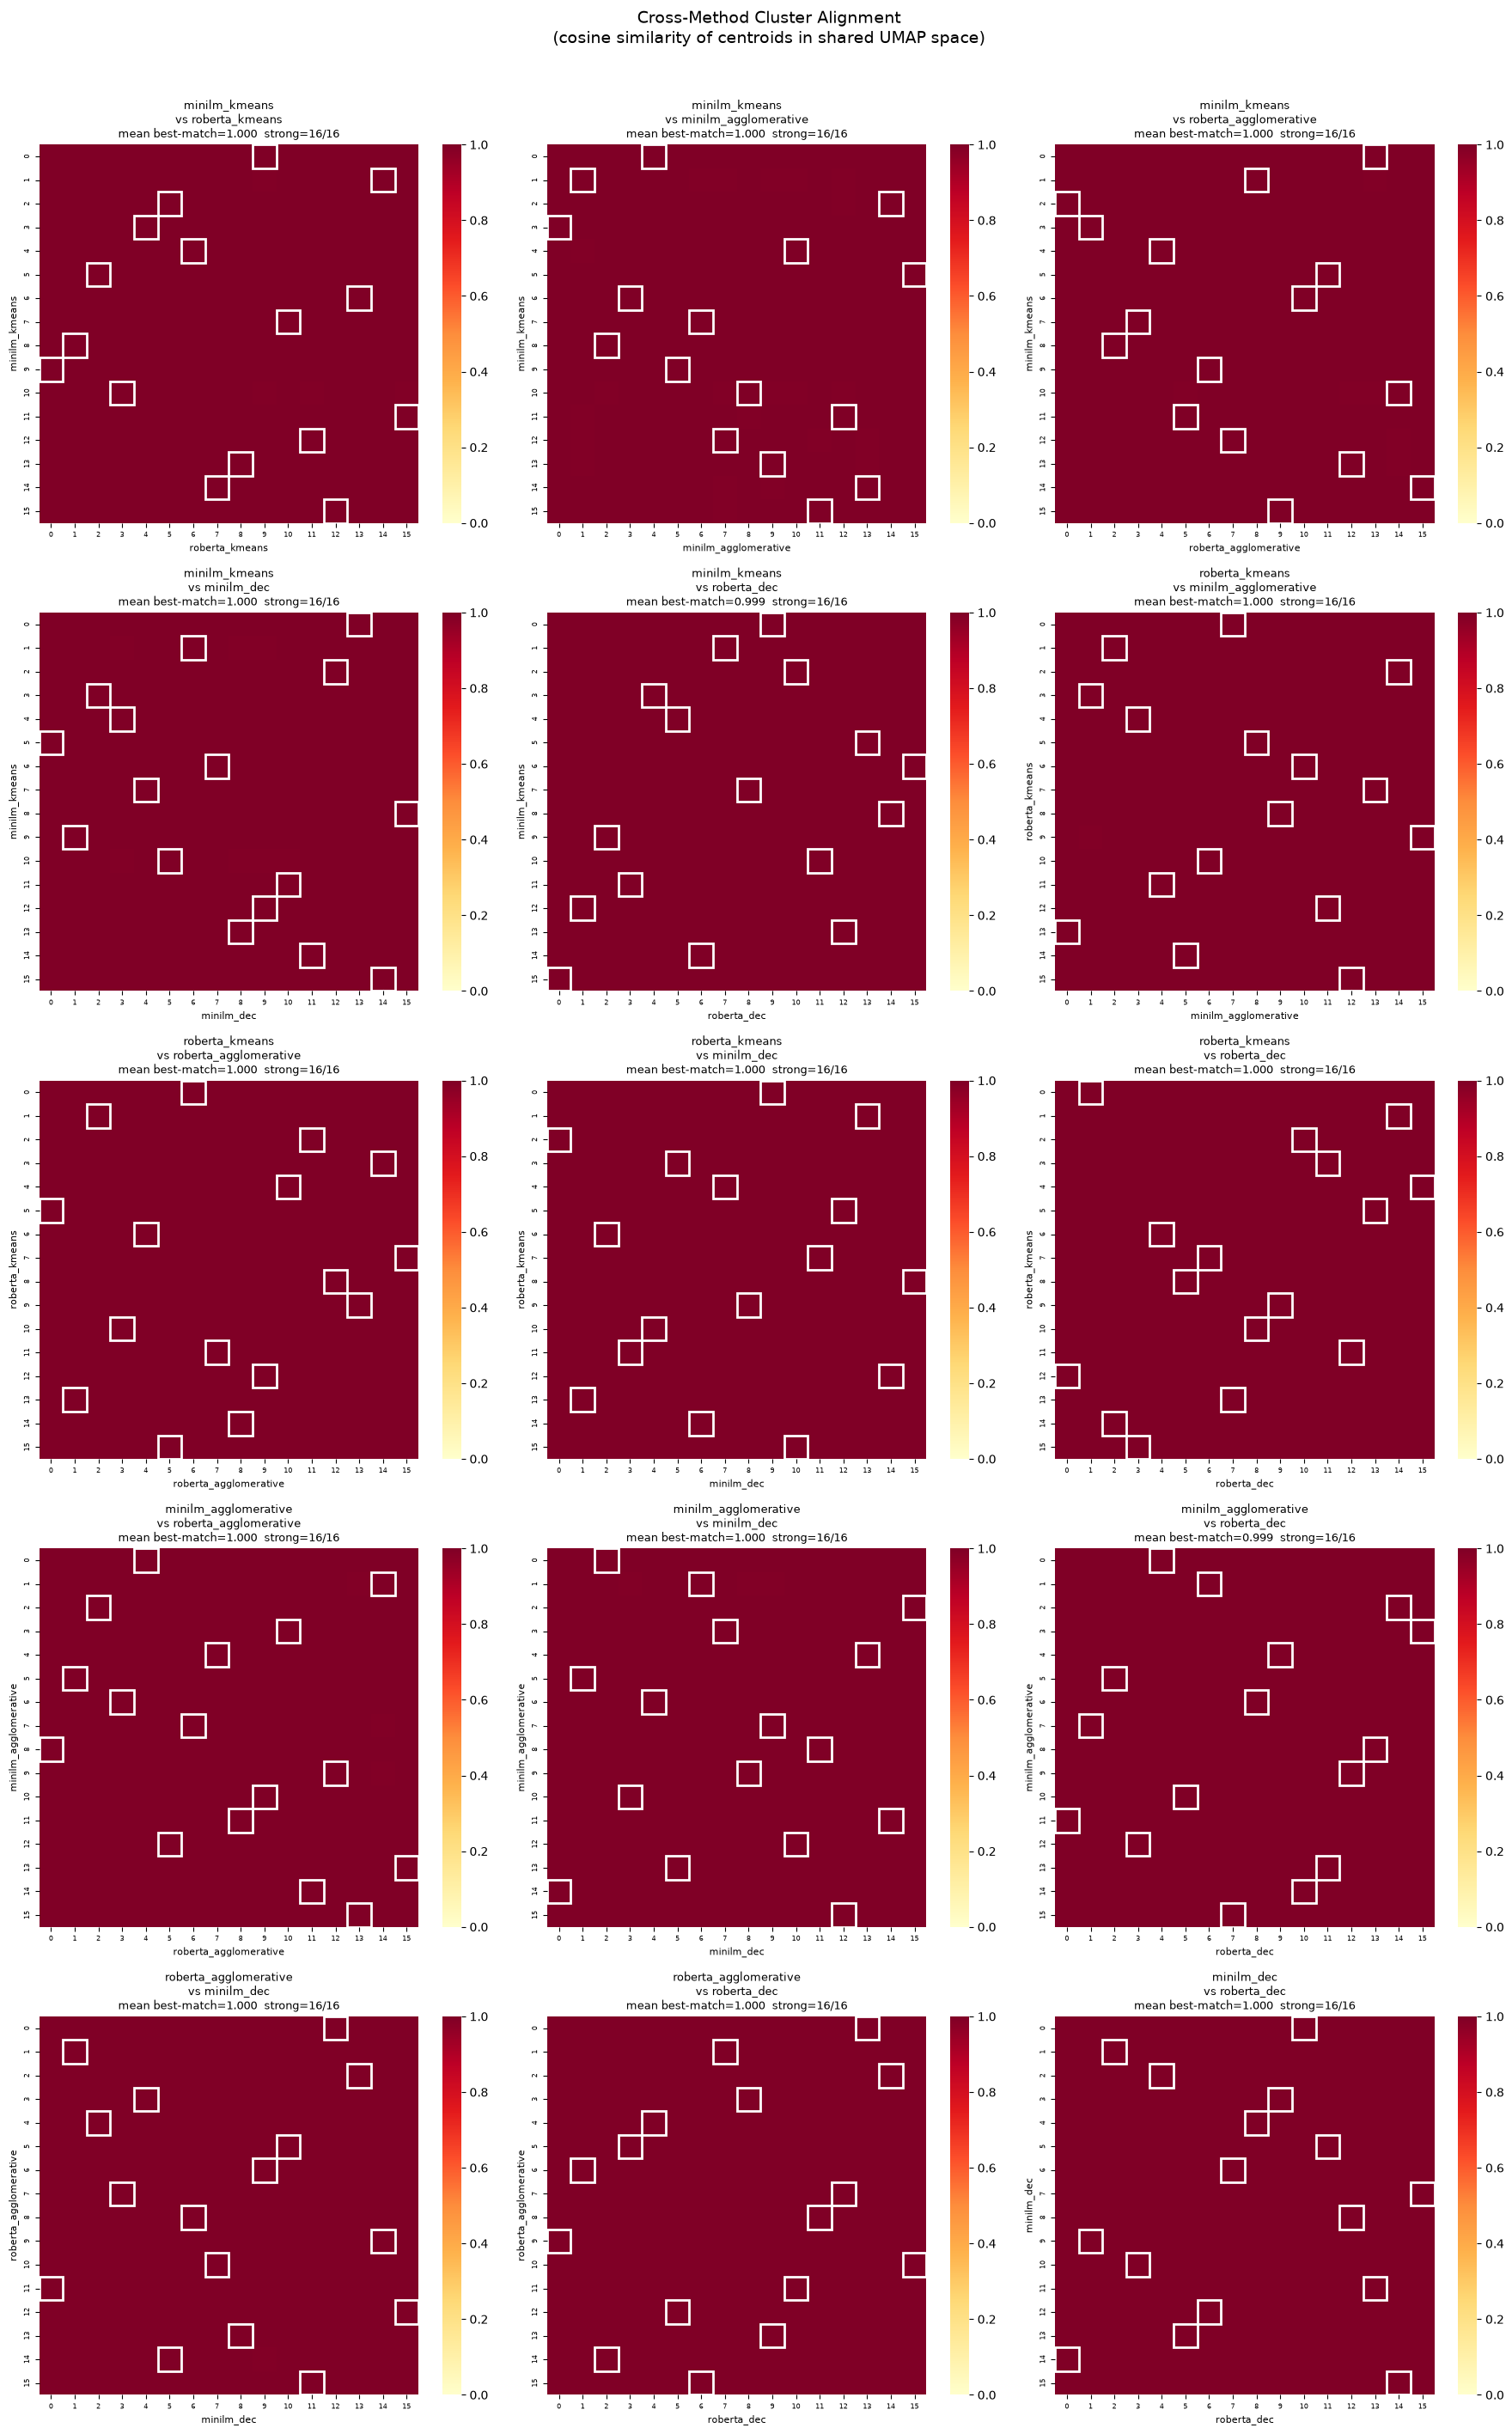

Saved: C:\Users\ACER\OneDrive\Documents\final-project\results\alignment_heatmap_all.png


In [5]:
# pairs defined here; cell 7 reuses it without recomputing
pairs = list(combinations(METHODS, 2))   # 15 pairs
assert len(pairs) == 15

fig, axes = plt.subplots(5, 3, figsize=(18, 28))
axes_flat = axes.flatten()

for ax, (method_a, method_b) in zip(axes_flat, pairs):
    sa, ea = method_index[method_a]
    sb, eb = method_index[method_b]
    sub = sim_matrix[sa:ea, sb:eb]   # (16, 16)

    # Hungarian matching: maximise similarity → minimise negative similarity
    row_ind, col_ind = linear_sum_assignment(-sub)
    mean_best = float(sub[row_ind, col_ind].mean())
    strong = int((sub[row_ind, col_ind] > STRONG_ALIGN_THRESHOLD).sum())

    sns.heatmap(
        sub,
        ax=ax,
        vmin=0, vmax=1,
        cmap="YlOrRd",
        cbar=True,
        xticklabels=range(N_CLUSTERS),
        yticklabels=range(N_CLUSTERS),
        linewidths=0,
    )

    # Annotate the Hungarian-matched pairs with white squares
    for r, c in zip(row_ind, col_ind):
        ax.add_patch(plt.Rectangle(
            (c, r), 1, 1,
            fill=False, edgecolor="white", lw=2,
        ))

    ax.set_title(
        f"{method_a}\nvs {method_b}\n"
        f"mean best-match={mean_best:.3f}  strong={strong}/{N_CLUSTERS}",
        fontsize=9,
    )
    ax.set_xlabel(method_b, fontsize=8)
    ax.set_ylabel(method_a, fontsize=8)
    ax.tick_params(labelsize=6)

fig.suptitle(
    "Cross-Method Cluster Alignment\n(cosine similarity of centroids in shared UMAP space)",
    fontsize=14, y=1.01,
)
plt.tight_layout()

out_path = REPO_ROOT / "results" / "alignment_heatmap_all.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")